# 🏎️ F1 Season Monte Carlo Simulator — Results Success Testing

This notebook loads the output CSVs from the Monte Carlo simulation and tests the predicted results against the actual results.

Each CSV represents 10,000+ simulated seasons. Values in each cell are the **probability** (0–1) that a given driver finishes the championship in that position.

---

In [ ]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install pathlib
%pip install fastf1
%pip install scikit-learn

## 0. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import fastf1
import os
from sklearn.calibration import calibration_curve
from datetime import datetime

year=datetime.now().year
current_directory = os.getcwd()

#Create project Directory Path
PROJECT_DIR = Path(current_directory).resolve().parent

#create Cache
CACHE_DIR=PROJECT_DIR / "fastf1_cache"
fastf1.Cache.enable_cache(CACHE_DIR)

#OUTPUT_DIR = Path("..") / f"csv_files/{next_race}"
GRAPH_DIR = Path("..") / f"graph_files/race_analysis"
CACHE_DIR = Path("..") / f"fastf1_cache/{year}"

CSV_DIR = Path("..") / f"csv_files"


# Plot styling
plt.rcParams['figure.facecolor'] = '#0f0f0f'
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#2a2a2a'
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['figure.dpi'] = 120

F1_RED = '#E8002D'
F1_SILVER = '#C0C0C0'

print('Setup complete.')

## 1. Load Data

In [ ]:
def load_sim_csv(filename):
    """Load a simulation output CSV. Index = driver codes, columns = finishing positions + DNF."""
    df = pd.read_csv( filename, index_col=0)
    # Ensure column names are strings for consistent handling
    df.columns = df.columns.astype(str)
    return df

#Create Variables
predicted_happened_races=[]
cached_races=[]
next_prediction_post=None

#pull current year schedule
schedule = fastf1.get_event_schedule(year)

#loop through cached races
for gp_dir in CACHE_DIR.iterdir():
    #find race folder
    race_folders = list(gp_dir.glob("*_Race"))
    if not race_folders:
        continue

    #find race folder
    race_folder = race_folders[0]
    if any(race_folder.iterdir()):
        #save which races are cached
        print(f"Race cached: {gp_dir.name}")
        cached_races.append(gp_dir)
    else:
        continue
        #print(f"No race data: {gp_dir.name}")

print(cached_races)
#loop through csv files
for race_file in CSV_DIR.rglob("*_race.csv"):
    #create named variables
    df = load_sim_csv(race_file)
    gp_name = race_file.parent.name
    formatted_gp_name=gp_name.replace(" ", "_")
    #check if the race has cached data
    if any(formatted_gp_name in str(path) for path in cached_races):
        print("Race exists in cache")
        #create index id for sorting later
        index_id=schedule.loc[schedule["EventName"]==gp_name,["RoundNumber"]]
        pre_true=race_file.name.startswith('pre')
        #specialize it for pre/post qualifying
        if(pre_true):
            index_id=str(index_id)[-1]+"_1pre"
        else:
            index_id=str(index_id)[-1]+"_2post"
        #save to dict of races that have happened and been predicted
        predicted_happened_races.append((race_file,gp_name,index_id))
    else:
        print(f"{gp_name} not in {cached_races}")
        #save for later analysis the predictions yet to happen
        if(race_file.name.startswith('pre')):
            next_prediction_pre=race_file
            next_prediction_pre=load_sim_csv(next_prediction_pre)
            print(next_prediction_pre)
        else:
            next_prediction_post=race_file
            next_prediction_post=load_sim_csv(next_prediction_post)
            print(next_prediction_post)

#sort races
sorted_races=sorted(predicted_happened_races, key=lambda x: x[2])

## 2. Double Check sorted_races

In [ ]:
#Create Variables
race_results={}
#loop through sorted races
for path,name,index_id in sorted_races:
    #load race result
    session=fastf1.get_session(year,name,"R")
    session.load(
        laps=False,
        telemetry=False,
        weather=False,
        messages=False
        )
    result=session.results
    #if a not occured race slipped through remove it
    if(result.empty):
        print(f"{name} RACE HASN'T HAPPENED")
        sorted_races.remove((path,name,index_id))
    #else save the result to list
    else:
        race_results[name] = {
            row["Abbreviation"]: row["ClassifiedPosition"]
            for _, row in result.iterrows()
        }

print(race_results)

## 3. RACE RESULT PREDICTION METRICS

Log Loss, Brier, and expected vs actual

In [ ]:
#function to calc log loss
def race_log_loss(df, actual):

    # align drivers
    df = df.loc[actual.index]
    #find columns
    cols = df.columns
    col_idx = cols.get_indexer(actual.values)
    row_idx = np.arange(len(df))
    #pull probability
    probs = df.to_numpy()[row_idx, col_idx]
    #calc log loss
    log_loss = -np.log(probs + 1e-15)

    return pd.DataFrame({
        "Driver": df.index,
        "Actual": actual.values,
        "Prob": probs,
        "LogLoss": log_loss
    })

#function to calc brier
def per_driver_brier(df, actual):
    #find columns
    cols = df.columns
    col_idx = cols.get_indexer(actual.values)
    row_idx = np.arange(len(df))
    #pull probability
    probs = df.to_numpy()[row_idx, col_idx]
    #calc brier
    brier = (1 - probs) ** 2

    return pd.DataFrame({
        "Driver": df.index,
        "Actual": actual.values,
        "Prob": probs,
        "Brier": brier
    })

#function to calc expected vs actual absolute error
def expected_vs_actual(df, actual):
    #remove DNF results
    finish_mask = actual != "DNF"
    df_finish = df.loc[finish_mask]
    actual_finish = actual[finish_mask]
    #find finish columns
    finish_cols = [c for c in df.columns if c != "DNF"]
    positions = np.array([int(c) for c in finish_cols])
    #calc expected and actual finishes
    expected_finish = df[finish_cols].to_numpy() @ positions
    actual_finish = pd.to_numeric(
        actual.replace("DNF", np.nan),
        errors="coerce"
    ).values
    #calc absolute error
    abs_error = np.where(
        ~np.isnan(actual_finish),
        np.abs(expected_finish - actual_finish),
        np.nan
    )

    return pd.DataFrame({
        "Driver": df.index,
        "ExpectedFinish": expected_finish,
        "ActualFinish": actual_finish,
        "AbsError": abs_error
    })

#calc expected finish
def expected(df):
    #find non DNF columns
    finish_cols = [c for c in df.columns if c != "DNF"]
    positions = np.array([int(c) for c in finish_cols])
    #calc expected finish
    expected_finish = df[finish_cols].to_numpy() @ positions

    return pd.DataFrame({
        "Driver": df.index,
        "ExpectedFinish": expected_finish
    })

#Create Variables
log_losses={}
briers={}
evas={}
#loop through sorted races
for path,name,index_id in sorted_races:
    print(name)
    #call prediction
    predictive_df=pd.read_csv(path)
    #normalize the dataframe
    df = predictive_df.rename(columns={"Unnamed: 0": "Driver"}).copy()
    df.columns = df.columns.astype(str)
    df = df.set_index("Driver")

    #pull race result for race [name] and normalize
    actual_dict=race_results[name]
    actual = pd.Series(actual_dict).astype(str).replace("R", "DNF")
    
    #find file stem
    df = df.loc[actual.index]
    file_stem=Path(path).stem
    full_index=name+"_"+file_stem

    log_losses[full_index]=(race_log_loss(df, actual))
    briers[full_index]=(per_driver_brier(df, actual))
    evas[full_index]=(expected_vs_actual(df, actual))

## 4. FULL SEASON RACE BY RACE LOG LOSS

Visualize the log loss trend over the season

In [ ]:
#create log loss graph
def log_loss_graph(df,name):
    #create Series
    log_df = pd.Series(df).reset_index()
    log_df.columns = ["Race", "LogLoss"]
    log_df["Rolling"] = log_df["LogLoss"].rolling(3).mean()

    #create graph
    plt.figure(figsize=(10,5))
    plt.plot(log_df["Race"], log_df["LogLoss"], alpha=0.5,color=F1_SILVER)
    plt.plot(log_df["Race"], log_df["Rolling"], linewidth=3,color=F1_RED)
    plt.plot(log_df["Race"], log_df["LogLoss"], marker="o",color=F1_SILVER)
    plt.xticks(rotation=45)
    plt.ylabel("Log Loss")
    plt.xlabel("Race")
    plt.title(f"{name} Race-by-Race Log Loss")
    plt.tight_layout()

    #find/create file path to save
    FOLDER_PATH=GRAPH_DIR /'race_v_seasons'
    FOLDER_PATH.mkdir(parents=True, exist_ok=True)
    #save and show graph
    plt.savefig(FOLDER_PATH / f"{name} Race-by-Race Log Loss.png", dpi=150,
        bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()

#pull driver metric
def driver_metric(metric_dict, driver, metric):
    return pd.Series({
        race: df.loc[df["Driver"] == driver, metric].iloc[0]
        for race, df in metric_dict.items()
    })
#pull multiple metrics
def driver_metrics(metric_dict, driver, metrics=None):
    if metrics is None:
        metrics = []

    return pd.Series({
        race: df.loc[df["Driver"] == driver, metrics].iloc[0]
        for race, df in metric_dict.items()
    })
#find all log loss and all briers
all_logloss = pd.concat(log_losses.values(), ignore_index=True)
all_briers = pd.concat(briers.values(), ignore_index=True)
#create Series of log loss
race_logloss = pd.Series({
    race: df["LogLoss"].mean()
    for race, df in log_losses.items()
})
#make log loss graph of all drivers
log_loss_graph(race_logloss,"Combined")
#make log loss graph for each driver
for driver in df.index:
    driver_log=driver_metric(log_losses,driver,"LogLoss")
    log_loss_graph(driver_log,driver)

## 5. Prediction Error by Driver

Visualize each drivers Absolute Error

In [ ]:
#find all Expected Vs Actual(EVA)
all_evas = pd.concat(evas.values(), ignore_index=True)

#find all driver abs error
driver_errors = (
    all_evas.groupby("Driver")["AbsError"]
    .mean()
    .sort_values()
)
#find max index value
max_idx = np.argmax(driver_errors)
#create array of colors for bars
colors = [F1_RED if i == max_idx else F1_SILVER for i in range(len(driver_errors))]
#make graph
plt.figure(figsize=(8,6))
driver_errors.plot(kind="barh",color=colors)
plt.xlabel("Average Absolute Error")
plt.ylabel("Driver")
plt.title("Prediction Error by Driver")
plt.tight_layout()

#find/create file path to save
FOLDER_PATH=GRAPH_DIR /'Predicted_Error'
FOLDER_PATH.mkdir(parents=True, exist_ok=True)
#save/show graph
plt.savefig(FOLDER_PATH / f"{sorted_races[-1][-1]} Predicted_Error_by_Driver.png", dpi=150,
    bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 6. Full Season Expected vs Actual Graph

Visualize the relationship between the expected finish and the actual finish

In [ ]:
#create EVA graph scatter plot
def expect_vs_actual(eva_list,name,next_prediction_post=None,next_prediction_pre=None):
    #create graph
    plt.figure(figsize=(8,8))
    plt.scatter(
        eva_list["ExpectedFinish"],
        eva_list["ActualFinish"],
        alpha=0.6,
        color=F1_SILVER
    )
    max_pos = max(
        eva_list["ExpectedFinish"].max(),
        eva_list["ActualFinish"].max()
    )
    plt.plot(
        [1, max_pos],
        [1, max_pos],
        linestyle="--",
        color=F1_RED
    )
    #plot X=next prediction line for both pre/post qualifying predictions
    if(name!="FULL"):
        expected_value=(next_prediction_pre[next_prediction_pre["Driver"]==driver]["ExpectedFinish"].values[0])
        plt.plot(
            [expected_value,expected_value],
            [1,max_pos],
            linestyle="--"
        )
        if(next_prediction_post is not None):
            expected_value_post=(next_prediction_pre[next_prediction_pre["Driver"]==driver]["ExpectedFinish"].values[0])
            plt.plot(
                [expected_value_post,expected_value_post],
                [1,max_pos],
                linestyle="--"
            )

    #label graph
    plt.xlabel("Expected Finish")
    plt.ylabel("Actual Finish")
    plt.title(f"{name} Expected vs Actual Finish Position")
    #find/create file path to save
    FOLDER_PATH=GRAPH_DIR /'Expected_vs_Actual'/f"{sorted_races[-1][-1]}"
    FOLDER_PATH.mkdir(parents=True, exist_ok=True)
    #show/save graph
    plt.savefig(FOLDER_PATH / f"{sorted_races[-1][-1]}_{name} Expected_vs_Actual.png", dpi=150,
        bbox_inches='tight', facecolor='#0f0f0f')
    plt.show()

#call function on all eva
expect_vs_actual(all_evas,"FULL")

#create scatterplot for each driver
for driver in df.index:
    driver_log=driver_metrics(evas,driver,["ExpectedFinish","ActualFinish"])
    driver_log = pd.DataFrame(driver_log.tolist(), index=driver_log.index)
    if(next_prediction_post is None):
        exepected_results_pre=expected(next_prediction_pre)
        expect_vs_actual(driver_log,driver,next_prediction_pre=exepected_results_pre)
    else:
        exepected_results_pre=expected(next_prediction_pre)
        exepected_results_post=expected(next_prediction_post)
        expect_vs_actual(driver_log,driver,next_prediction_pre=exepected_results_pre,next_prediction_post=exepected_results_post)

## 7. Expected vs Actual Finish Difference Graph

Visualize the trends in error by expected finish position

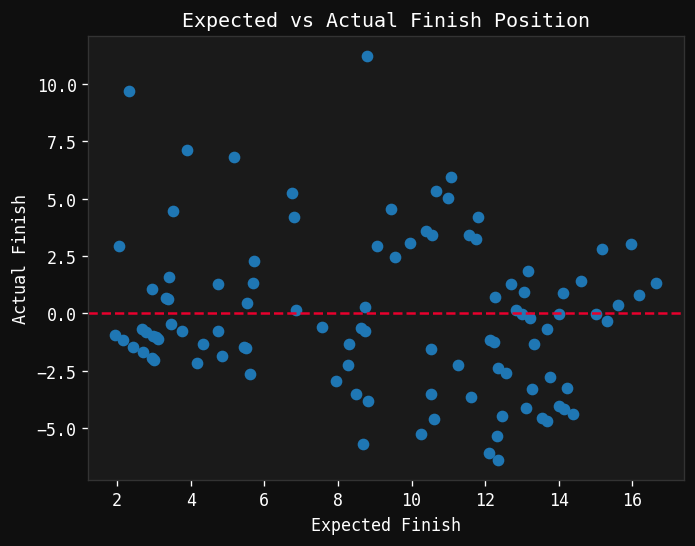

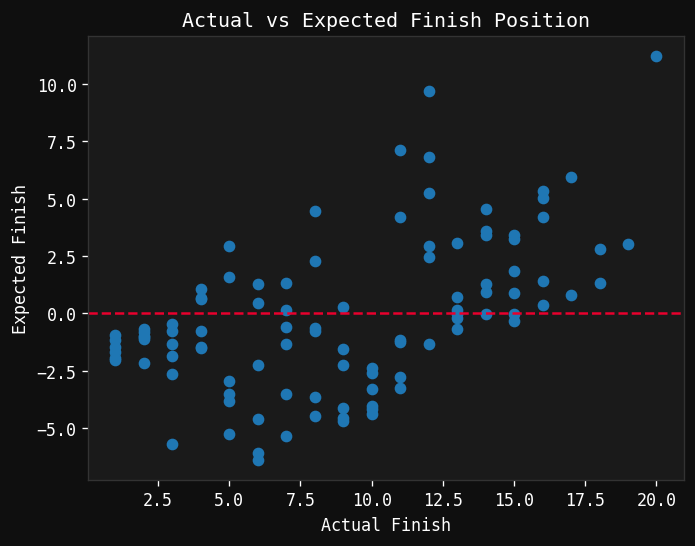

In [127]:
#find residual EVA
all_evas["Residual"] = (
    all_evas["ActualFinish"]
    - all_evas["ExpectedFinish"]
)
#create scatterplot for expected vs actual
plt.scatter(
    all_evas["ExpectedFinish"],
    all_evas["Residual"]
)
plt.axhline(0, linestyle="--",color=F1_RED)
plt.xlabel("Expected Finish")
plt.ylabel("Actual Finish")
plt.title("Expected vs Actual Finish Position")
#find/create file path to save
FOLDER_PATH=GRAPH_DIR /'Expected_Diff'
FOLDER_PATH.mkdir(parents=True, exist_ok=True)
#save/show graph
plt.savefig(FOLDER_PATH / f"{sorted_races[-1][-1]} Expected_Diff.png", dpi=150,
    bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

#create scatterplot for actual vs expected
plt.scatter(
    all_evas["ActualFinish"],
    all_evas["Residual"]
)
plt.axhline(0, linestyle="--",color=F1_RED)
plt.xlabel("Actual Finish")
plt.ylabel("Expected Finish")
plt.title("Actual vs Expected Finish Position")
#find/create file path to save
FOLDER_PATH=GRAPH_DIR /'Actual_Diff'
FOLDER_PATH.mkdir(parents=True, exist_ok=True)
#save/show graph
plt.savefig(FOLDER_PATH / f"{sorted_races[-1][-1]} Actual_Diff.png", dpi=150,
    bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 8. Previous Race Probability

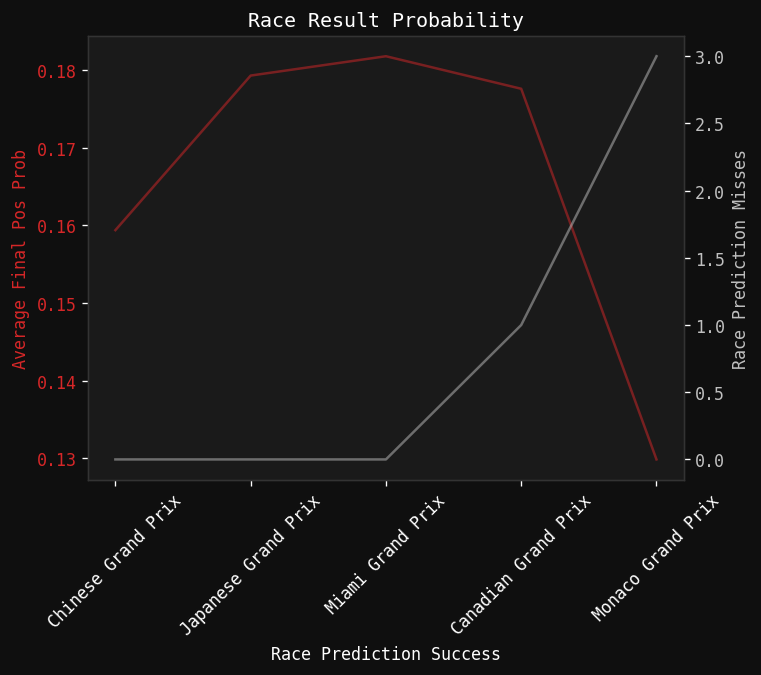

In [128]:
#Create Variables
odds={}
y_axis1={}
y_axis2={}
#loop through sorted races
for path,name,index_id in sorted_races:
    #create sub list
    odds[name]={}
    y_axis1[name]={}
    y_axis2[name]={}
    odds[name]["guessed"]={}
    odds[name]["missed"]={}
    #pull csv and modify
    predictive_df=pd.read_csv(path)
    df = predictive_df.rename(columns={"Unnamed: 0": "Driver"}).copy()
    df.columns = df.columns.astype(str)
    df = df.set_index("Driver")
    #pull actual results
    actual_dict=race_results[name]
    actual = pd.Series(actual_dict).astype(str).replace("R", "DNF").astype(str).replace("W", "DNF")
    #modify variables
    df = df.loc[actual.index]
    race_odds=1
    race_miss=0
    drive_count=0
    #pull result data
    for driver in df.index:
        real=(actual[driver])
        prob_=df.loc[driver][real]
        #find probability of the actual finish position
        race_odds+=prob_
        drive_count+=1
        #if probabilty is 0, add to counter
        if(prob_==0):
            race_miss+=1
    #find average place probability
    race_odds=race_odds/drive_count
    #save values
    odds[name]["guessed"]=race_odds
    odds[name]["missed"]=race_miss
    y_axis1[name]=race_odds
    y_axis2[name]=race_miss
#make list of y axis points
y1 = list(y_axis1.values())
y2 = list(y_axis2.values())
#make list of x axis points
x_axis = list(y_axis1.keys())

#make graph
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_xlabel('Race Prediction Success')
ax1.set_ylabel('Average Final Pos Prob',color=color)
ax1.plot(x_axis,y1,color=color, alpha=0.5)
ax1.tick_params(axis='y', labelcolor=color)

ax2=ax1.twinx()
color = F1_SILVER
ax2.set_ylabel('Race Prediction Misses',color=color)
ax2.plot(x_axis,y2,color=color, alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color)
#clean graph display
ax1.tick_params(axis='x',rotation=45)
plt.title("Race Result Probability")
#find/create file path to save
FOLDER_PATH=GRAPH_DIR /'Race_Probability'
FOLDER_PATH.mkdir(parents=True, exist_ok=True)
#save/show graph
plt.savefig(FOLDER_PATH / f"Finish Probability.png", dpi=150,
    bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---

## Summary

| Chart | File | Description |
|---|---|---|
| Full Season Race by Race Combined Log Loss Line | `Combined Race-by-Race Log loss.png` | Log Loss Total of Each Race for Combined |
| Full Season Race by Race per Driver Log Loss Line | `{name} Race-by-Race Log loss.png` | Log Loss Total of Each Race for Each Driver |
| Prediction Error by Driver Bar | `[race[-1]] Predicted_Error_by_Driver.png` | Absolute Error by Driver |
| Season vs Expected Combined Scatter | `[race[-1]]_FULL Expected_vs_Actual.png` | Actual vs Expected Result Combined |
| Season vs Expected by Driver Scatter | `[race[-1]]_[name] Expected_vs_Actual.png` | Actual vs Expected Result by Driver |
| Expected vs Actual Scatter | `[race[-1]] Expected_Diff.png` | Expected vs Difference to Actual |
| Actual vs Expected Scatter | `[race[-1]] Actual_Diff.png` | Actual vs Difference to Expected |
| Race Result Probabilty and Miss Line | `Finish Probability.png` | Average Final Position Probability and Missed Prediction by Race |

All charts are saved to `graph_files/race_analysis` and can be used directly in LinkedIn posts or reports.